In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from cuml.decomposition import PCA
from cuml.manifold import UMAP


# fill these
RUN_NAME = "..."
PATH_EMBEDDINGS = Path("...")
PATH_TRACK_LOOKUP = Path("...")
PATH_OUTPUT_DIR = Path("...")


if not isinstance(RUN_NAME, str):
    raise ValueError("Set RUN_NAME to the run tag string, e.g. 'vivid_dragon'")
if not PATH_EMBEDDINGS.exists():
    raise FileNotFoundError(f"Could not find `{PATH_EMBEDDINGS}`")
print(f"Set embedding to `{PATH_EMBEDDINGS}`")
if not PATH_TRACK_LOOKUP.exists():
    raise FileNotFoundError(f"Could not find `{PATH_TRACK_LOOKUP}`")
print(f"Set track lookup to `{PATH_TRACK_LOOKUP}`")
PATH_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Set output directory to `{PATH_OUTPUT_DIR}`.")

Set embedding to `/home/ubuntu/assets/models/magic_falcon/magic_falcon_embeddings_tracks.parquet`
Set track lookup to `/home/ubuntu/assets/data/track_lookup.parquet`
Set output directory to `/home/ubuntu/outs`.


In [2]:
print("Loading embeddings ...")
embs_df = pd.read_parquet(PATH_EMBEDDINGS)
emb_cols = [c for c in embs_df.columns if c.startswith("e") and c[1:].isdigit()]
print(f"{len(embs_df):,} tracks × {len(emb_cols)} dims")

print("Loading lookup ...")
lookup_df = pd.read_parquet(PATH_TRACK_LOOKUP)
print(f"{len(lookup_df):,} tracks × {len(lookup_df.columns)} dims")

embs_meta = embs_df[["track_rowid"]].merge(
    lookup_df[["track_rowid", "logcounts", "track_name", "artist_name"]],
    on="track_rowid",
    how="left",
)

Loading embeddings ...
8,644,299 tracks × 128 dims
Loading lookup ...
27,176,693 tracks × 11 dims


# Track embeddings

In [24]:
nn = 170
md = 0.001
local_connectivity = 1.00
spread = 2.50
metric = "cosine"
init = "spectral"
random_state = None

# PCA pre-projection: reduce to PCA_DIMS before UMAP.
# Set to None to skip PCA.
PCA_DIMS = None

# Top-N tracks by logcount for UMAP fit. None = use full dataset.
N_SAMPLE = 4_000_000

In [25]:
TRANSFORM_BATCH_SIZE = 2_000_000

## PCA

In [26]:
matrix = embs_df[emb_cols].to_numpy(dtype=np.float32)

if PCA_DIMS is not None:
    print(f"PCA {matrix.shape[1]}d → {PCA_DIMS}d ...")
    pca = PCA(n_components=PCA_DIMS)
    matrix = pca.fit_transform(matrix)
    print(f"  explained variance ratio sum: {pca.explained_variance_ratio_.sum():.3f}")
else:
    pca = None

## UMAP Fit

In [27]:
umap_params = dict(
    n_neighbors=nn,
    min_dist=md,
    local_connectivity=local_connectivity,
    spread=spread,
    metric=metric,
    init=init,
    random_state=random_state,
)
reducer = UMAP(n_components=2, **umap_params, verbose=False)

if N_SAMPLE is not None and N_SAMPLE < len(embs_df):
    sample_idx = embs_meta["logcounts"].nlargest(N_SAMPLE).index.to_numpy()
    sample_matrix = matrix[sample_idx]
    print(f"Sample: {len(sample_idx):,} / {len(matrix):,} tracks (top by logcount)")
else:
    sample_idx = None
    sample_matrix = matrix
    print(f"Using full dataset: {len(matrix):,} tracks")

coords = reducer.fit_transform(sample_matrix)
export_rowids = embs_df["track_rowid"].values[sample_idx] if sample_idx is not None else embs_df["track_rowid"].values
print(f"fit_transform done. ({len(coords):,} rows)")

Sample: 4,000,000 / 8,644,299 tracks (top by logcount)
[2026-03-25 17:36:32.181] [CUML] [warning] build_algo='nn_descent' requires `nnd_graph_degree >= n_neighbors`. Setting nnd_graph_degree to 170
[2026-03-25 17:36:32.181] [CUML] [warning] build_algo='nn_descent' requires `nnd_intermediate_graph_degree >= nnd_graph_degree`. Setting nnd_intermediate_graph_degree to 170
fit_transform done. (4,000,000 rows)


## UMAP Transform

In [32]:
def batch_transform(matrix, reducer, batch_size):
    """Transform matrix in batches. Returns (N, 2) float32 array."""
    n = len(matrix)
    chunks = []
    for lo in range(0, n, batch_size):
        hi = min(lo + batch_size, n)
        chunks.append(reducer.transform(matrix[lo:hi]))
        print(f"  {hi:,} / {n:,}", end="\r", flush=True)
    print()
    return np.vstack(chunks)


# Run this cell to project the full dataset onto the fitted reducer.
# Re-run the track_df cell below to update it with all-tracks coordinates.
coords = batch_transform(matrix, reducer, TRANSFORM_BATCH_SIZE)
export_rowids = embs_df["track_rowid"].values
print(f"Done. ({len(coords):,} rows)")

  8,644,299 / 8,644,299
Done. (8,644,299 rows)


In [33]:
md_str = str(md).replace(".", "d")

track_df = pd.DataFrame({
    "track_rowid": export_rowids,
    "umap_x": coords[:, 0].astype(np.float32),
    "umap_y": coords[:, 1].astype(np.float32),
})

# Visualize

In [34]:
BINS = 1000

x = track_df["umap_x"].to_numpy()
y = track_df["umap_y"].to_numpy()

x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

cx, cy = (x_min + x_max) / 2, (y_min + y_max) / 2
print(f"x  [{x_min:.3f}, {x_max:.3f}]  range {x_max - x_min:.3f}  center {cx:.3f}  std {x.std():.3f}")
print(f"y  [{y_min:.3f}, {y_max:.3f}]  range {y_max - y_min:.3f}  center {cy:.3f}  std {y.std():.3f}")
print(f"{len(x):,} points")

xi = np.clip(((x - x_min) / (x_max - x_min) * BINS).astype(np.int32), 0, BINS - 1)
yi = np.clip(((y - y_min) / (y_max - y_min) * BINS).astype(np.int32), 0, BINS - 1)

heatmap = np.bincount(yi * BINS + xi, minlength=BINS * BINS).reshape(BINS, BINS)

viz = track_df.merge(
    embs_meta[["track_rowid", "artist_name", "track_name", "logcounts"]],
    on="track_rowid",
    how="left",
)

x  [-17.451, 17.938]  range 35.388  center 0.244  std 7.417
y  [-20.062, 15.544]  range 35.606  center -2.259  std 8.005
8,644,299 points


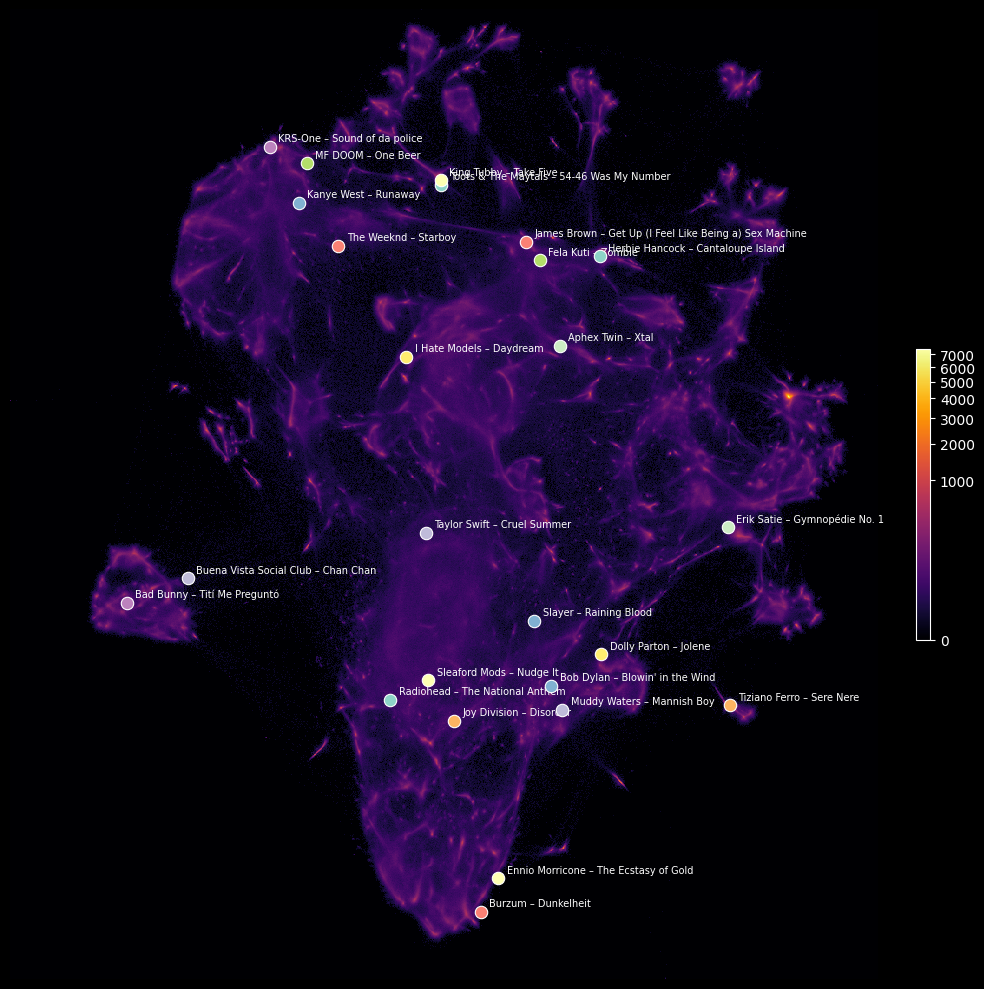

In [35]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm


def plot_umap(highlights=None):
    """Plot the UMAP heatmap with optional track overlays.

    highlights: list of (artist, track_name) tuples (case-insensitive).
                Unmatched entries are printed as warnings.
    """
    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=(10, 10))
        im = ax.imshow(
            heatmap,
            origin="lower",
            norm=PowerNorm(gamma=0.3, vmin=0., vmax=heatmap.max()),
            cmap="inferno",
            interpolation="nearest",
            extent=[x_min, x_max, y_min, y_max],
            aspect="auto",
        )
        fig.colorbar(im, ax=ax, fraction=0.046, shrink=0.3, pad=0.04)
        ax.set_axis_off()

        if highlights:
            for artist, track in highlights:
                matches = viz[
                    (viz["artist_name"].str.lower() == artist.lower()) &
                    (viz["track_name"].str.lower() == track.lower())
                ]
                if matches.empty:
                    print(f"  not found: {artist!r} – {track!r}")
                    continue
                row = matches.sort_values("logcounts", ascending=False).iloc[0]
                ax.scatter(row["umap_x"], row["umap_y"], s=80, zorder=5,
                           edgecolors="white", linewidths=0.8)
                ax.annotate(f"{artist} – {track}", (row["umap_x"], row["umap_y"]),
                            fontsize=7, color="white",
                            xytext=(6, 4), textcoords="offset points")

        plt.tight_layout()
        plt.show()


highlights = [
    ("Radiohead", "The National Anthem"),
    ("Sleaford Mods", "Nudge It"),
    ("Taylor Swift", "Cruel Summer"),
    ("Burzum", "Dunkelheit"),
    ("Slayer", "Raining Blood"),
    ("Joy Division", "Disorder"),
    ("MF DOOM", "One Beer"),
    ("KRS-One", "Sound of da police"),
    ("Aphex Twin", "Xtal"),
    ("I Hate Models", "Daydream"),
    ("Herbie Hancock", "Cantaloupe Island"),
    ("Ennio Morricone", "The Ecstasy of Gold"),
    ("Buena Vista Social Club", "Chan Chan"),
    ("The Weeknd", "Starboy"),
    ("Kanye West", "Runaway"),
    ("Tiziano Ferro", "Sere Nere"),
    ("Fela Kuti", "Zombie"),
    ("Bad Bunny", "Tití Me Preguntó"),
    ("Erik Satie", "Gymnopédie No. 1"),
    ("Dolly Parton", "Jolene"),
    ("Toots & The Maytals", "54-46 Was My Number"),
    ("King Tubby", "Take Five"),
    ("Muddy Waters", "Mannish Boy"),
    ("James Brown", "Get Up (I Feel Like Being a) Sex Machine"),
    ("Bob Dylan", "Blowin' in the Wind"),
]

plot_umap(highlights)

# Export

In [36]:
import time

from src.entities import Albums, Artists, Labels

if len(track_df) < len(embs_df):
    print(f"Exploration mode ({len(track_df):,} / {len(embs_df):,} tracks) — run the transform cell first.")
else:
    written = []

    out = PATH_OUTPUT_DIR / f"{RUN_NAME}_umap_track_2d_nn{nn}_md{md_str}_{metric}.parquet"
    track_df.to_parquet(out, index=False)
    print(f"  → {out}  ({len(track_df):,} rows)")
    written.append(out)

    for entity_cls, entity_name, rowid_col in [
        (Albums,  "album",  "album_rowid"),
        (Artists, "artist", "artist_rowid"),
        (Labels,  "label",  "label"),
    ]:
        entity_df = entity_cls.embeddings(embs_df, lookup_df)
        m = entity_df[emb_cols].to_numpy(dtype=np.float32)
        if pca is not None:
            m = pca.transform(m)
        entity_coords = batch_transform(m, reducer, TRANSFORM_BATCH_SIZE)
        df = pd.DataFrame({
            rowid_col: entity_df[rowid_col].values,
            "umap_x": entity_coords[:, 0].astype(np.float32),
            "umap_y": entity_coords[:, 1].astype(np.float32),
        })
        out = PATH_OUTPUT_DIR / f"{RUN_NAME}_umap_{entity_name}_2d_nn{nn}_md{md_str}_{metric}.parquet"
        df.to_parquet(out, index=False)
        print(f"  → {out}  ({len(df):,} rows)")
        written.append(out)

    log_path = PATH_OUTPUT_DIR / "umap_runs.log"
    with open(log_path, "a") as f:
        f.write(f"{time.strftime('%Y-%m-%d %H:%M:%S')}  {RUN_NAME}\n")
        f.write(
            f"  nn={nn}  md={md}  metric={metric}  spread={spread}"
            f"  lc={local_connectivity}  init={init}  rs={random_state}"
            f"  pca={PCA_DIMS}  sample={N_SAMPLE}  n_tracks={len(track_df)}\n"
        )
        for p in written:
            f.write(f"  {p.name}\n")
        f.write("\n")
    print(f"  log → {log_path}")

  → /home/ubuntu/outs/magic_falcon_umap_track_2d_nn170_md0d001_cosine.parquet  (8,644,299 rows)
  420,499 / 420,499
  → /home/ubuntu/outs/magic_falcon_umap_album_2d_nn170_md0d001_cosine.parquet  (420,499 rows)
  171,555 / 171,555
  → /home/ubuntu/outs/magic_falcon_umap_artist_2d_nn170_md0d001_cosine.parquet  (171,555 rows)
  10,158 / 10,158
  → /home/ubuntu/outs/magic_falcon_umap_label_2d_nn170_md0d001_cosine.parquet  (10,158 rows)
  log → /home/ubuntu/outs/umap_runs.log
